# Tutorial 2 (part 2): Modelling time series with CNNs
By Prof Ivan Olier

## Introduction

With This tutorial, you will practise how to model time series with CNN layers.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


## Dataset
We will use a database of 1-lead ECGs (electrocardiograms) consisting of three classes: Atrial Fibrillation, Normal Sinus, and noise.

* Download the dataset file from Canvas.

In [14]:
# Read the data
data = np.load('./cinc_samp.npz')  # Use your own path here!
data.files

['arr_0', 'arr_1']

In [15]:
X = data['arr_0']  # Input time series
y = data['arr_1']  # Classes
print(X.shape)
print(y.shape)

(6072, 900)
(6072, 3)


In [16]:
# Suponiendo una duración por ecg de 10s
t = np.linspace(0, 10, 900)

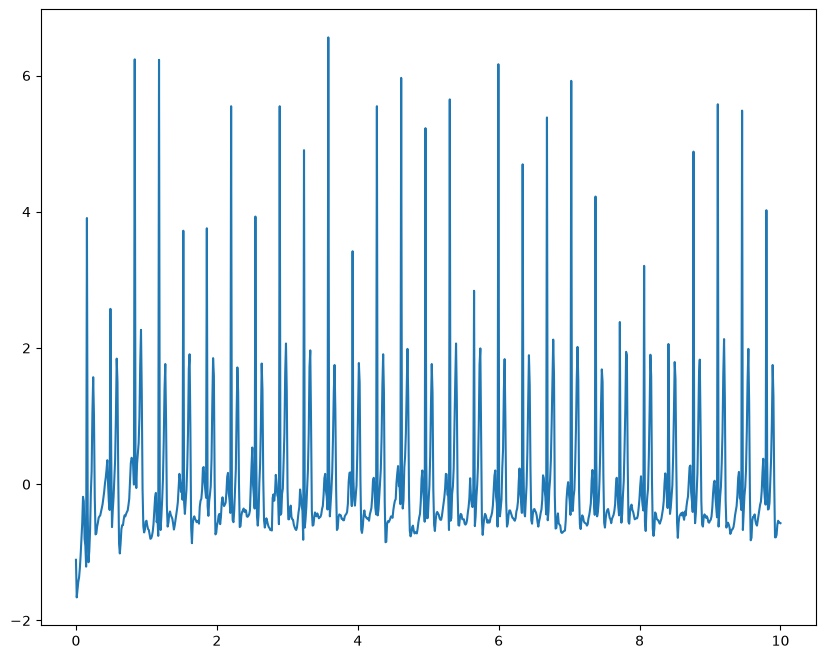

In [17]:
plt.figure(figsize=(10,8))
plt.plot(t, X[19,:])

## Pre-processing

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=1234)

In [19]:
from sklearn import preprocessing
mm_scaler = preprocessing.StandardScaler()
X_train = mm_scaler.fit_transform(X_train)
X_test = mm_scaler.transform(X_test)

In [20]:
y_train[0:10,]

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

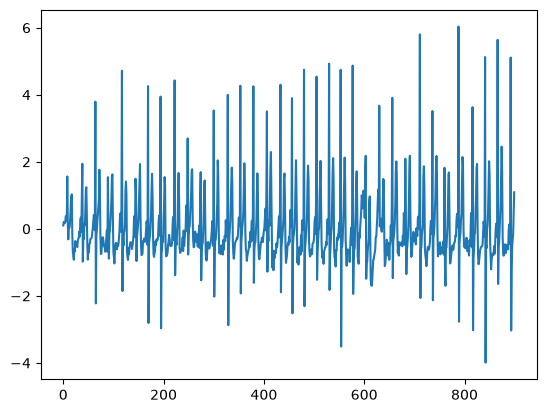

In [21]:
plt.figure()
plt.plot(X_train[19,:])

In [22]:
X_train = np.expand_dims(X_train, axis=2)

## Building the model with *keras*

In [23]:
from tensorflow.keras.backend import clear_session
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPool1D

I0000 00:00:1782333020.640706   36262 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782333021.209115   36262 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782333022.452214   36262 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [24]:
ecg_mdl = Sequential()
ecg_mdl.add(Input(shape=(900,1)))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Conv1D(filters=16, kernel_size=8, padding='same', activation='relu'))
ecg_mdl.add(MaxPool1D(pool_size=3))
ecg_mdl.add(Flatten())
ecg_mdl.add(Dense(3, activation='softmax'))
ecg_mdl.summary()


I0000 00:00:1782333025.516216   36262 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 900, 16)        │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 300, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 16)        │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 16)        │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 33, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 33, 16)         │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 11, 16)         │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 3, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3, 16)          │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,515 (41.07 KB)

 Trainable params: 10,515 (41.07 KB)

 Non-trainable params: 0 (0.00 B)

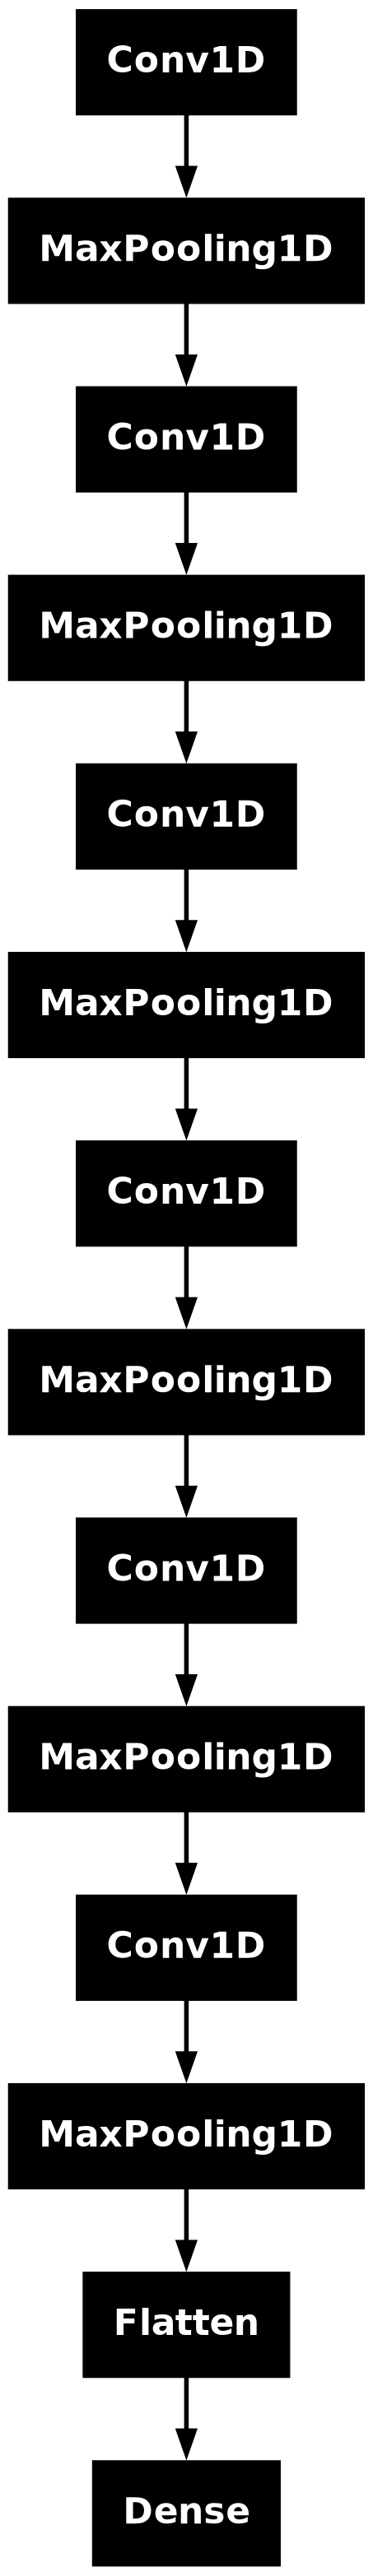

In [25]:
from tensorflow.keras.utils import plot_model
plot_model(ecg_mdl)

In [26]:
ecg_mdl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
from tensorflow.keras.callbacks import EarlyStopping
custom_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.001
)

In [28]:
history = ecg_mdl.fit(x = X_train, y = y_train,
                     batch_size=32,
                     epochs = 100,
                     validation_split=0.2,
                     callbacks=[custom_early_stopping])

Epoch 1/100


I0000 00:00:1782333027.670525   36659 service.cc:153] XLA service 0x79a2f4035340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782333027.670540   36659 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782333027.717025   36659 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782333027.982058   36659 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782333028.005997   36659 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2866__.69


 28/122 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.8227

I0000 00:00:1782333033.582738   36659 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


117/122 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7810 - loss: 0.6410

I0000 00:00:1782333034.306152   36659 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2866__.69


122/122 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.8196 - loss: 0.5510 - val_accuracy: 0.8107 - val_loss: 0.5183
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.4286 - val_accuracy: 0.8374 - val_loss: 0.4061
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8698 - loss: 0.3552 - val_accuracy: 0.8549 - val_loss: 0.3641
Epoch 4/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8885 - loss: 0.2954 - val_accuracy: 0.8714 - val_loss: 0.3287
Epoch 5/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9017 - loss: 0.2709 - val_accuracy: 0.9043 - val_loss: 0.2591
Epoch 6/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9086 - loss: 0.2363 - val_accuracy: 0.9012 - val_loss: 0.2508
Epoch 7/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.2251 - val_accuracy: 0.9043 - val_loss: 0.2691
Epoch 8/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9218 - loss: 0.2131 - val_accuracy: 0.88

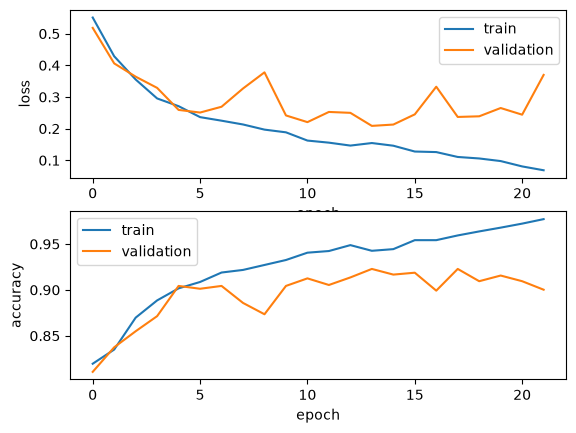

In [29]:
def plot_history(history):
    plt.figure()
    plt.subplot(2,1,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])
    plt.subplot(2,1,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])
    return;

plot_history(history)

In [30]:
X_test = np.expand_dims(X_test, axis=2)

In [31]:
ecg_mdl.evaluate(x=X_test, y=y_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9366 - loss: 0.2361


[0.23614861071109772, 0.9366255402565002]

In [32]:
y_pred = ecg_mdl.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step 


In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
print(cm)

[[  86   46    5]
 [   1 1018    7]
 [   0   18   34]]


## Exercise

Run several CNN models with hyperparameters changed to find a better performing model. Produce a boxplot that summarises test model performances and which options seem to benefit more the models.
